In [2]:
import networkx as nx

# Grafos DARPA E3

## 20180406 1100 CADETS – Nginx Backdoor w/ Drakon In-Memory

In [4]:


# Crear el grafo dirigido
G = nx.DiGraph()

# Definir los nodos con su forma asociada (todos parecen rectángulos en amarillo, pero lo ajustaremos si es necesario)
nodes_with_shapes = {
    "81.49.200.166": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "nginx": {"shape": "rectangle", "attackrelevant": "A"},
    "78.205.235.65:80": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "200.36.109.214:80": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "/dev/gia_alia_675": {"shape": "ellipse", "attackrelevant": "A"},
    "/tmp/vUgefal": {"shape": "ellipse", "attackrelevant": "A"},
    "vUgefal (PID 7)": {"shape": "rectangle", "attackrelevant": "A"},
    "/etc/group": {"shape": "ellipse", "attackrelevant": "A"},
    "139.123.0.113:80": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "154.143.113.18:80": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "61.167.39.128:80": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "/etc/passwd": {"shape": "ellipse", "attackrelevant": "A"},
    "sshd (PID 8000)": {"shape": "rectangle", "attackrelevant": "A"},
    "/var/log/devc": {"shape": "ellipse", "attackrelevant": "A"},
    #"kernel panic": {"shape": "ellipse", "attackrelevant": "A"}
}

# Añadir los nodos al grafo con el atributo "shape"
for node, dicti in nodes_with_shapes.items():
    G.add_node(node, shape=dicti["shape"], attackrelevant=dicti["attackrelevant"])

# Definir las aristas basadas en las relaciones observadas en el grafo
edges = [
    ("81.49.200.166", "nginx", {"label": "connect"}),
    ("nginx", "78.205.235.65:80", {"label": "connect"}),
    ("nginx", "200.36.109.214:80", {"label": "connect"}),
    ("nginx", "/dev/gia_alia_675", {"label": "write"}),
    ("nginx", "/etc/group", {"label": "read"}),
    ("nginx", "/etc/passwd", {"label": "read"}),
    ("nginx", "/tmp/vUgefal", {"label": "delete"}),
    ("nginx", "/tmp/vUgefal", {"label": "putfile"}),
    ("/dev/gia_alia_675", "/tmp/vUgefal", {"label": "execute"}),
    ("/tmp/vUgefal", "vUgefal (PID 7)", {"label": "create (new process)"}),
    ("vUgefal (PID 7)", "/etc/group", {"label": "read"}),
    ("vUgefal (PID 7)", "139.123.0.113:80", {"label": "connect"}),
    ("vUgefal (PID 7)",  "154.143.113.18:80", {"label": "connect"}),
    ("vUgefal (PID 7)", "61.167.39.128:80", {"label": "connect"}),
    ("vUgefal (PID 7)", "/var/log/devc", {"label": "chmod"}),
    ("vUgefal (PID 7)", "/var/log/devc", {"label": "write"}),
    ("vUgefal (PID 7)", "sshd (PID 8000)", {"label": "inject"}),
    ("vUgefal (PID 7)", "/etc/passwd", {"label": "read"}),
    #("sshd (PID 8000)", "kernel panic", {"label": "crash"}),
]

# Añadir las aristas al grafo
G.add_edges_from(edges)


In [ ]:
# Exportar el grafo a formato GEXF
output_path = "./grafo1_E3.gexf"

nx.write_gexf(G, output_path)
# Dibujar el grafo
pos = nx.forceatlas2_layout(G)  # Layout para distribuir los nodos
plt.figure(figsize=(14, 10))

# Dibujar nodos con diferentes formas
shapes = set(nx.get_node_attributes(G, 'shape').values())
for shape in shapes:
    node_list = [node for node in G.nodes if G.nodes[node]['shape'] == shape]
    nx.draw_networkx_nodes(G, pos, nodelist=node_list, node_shape="send", node_color="yellow", node_size=700)

nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Grafo generado a partir de la imagen")
plt.show()


## 20180406 1500 ClearScope – Phishing E-mail Link

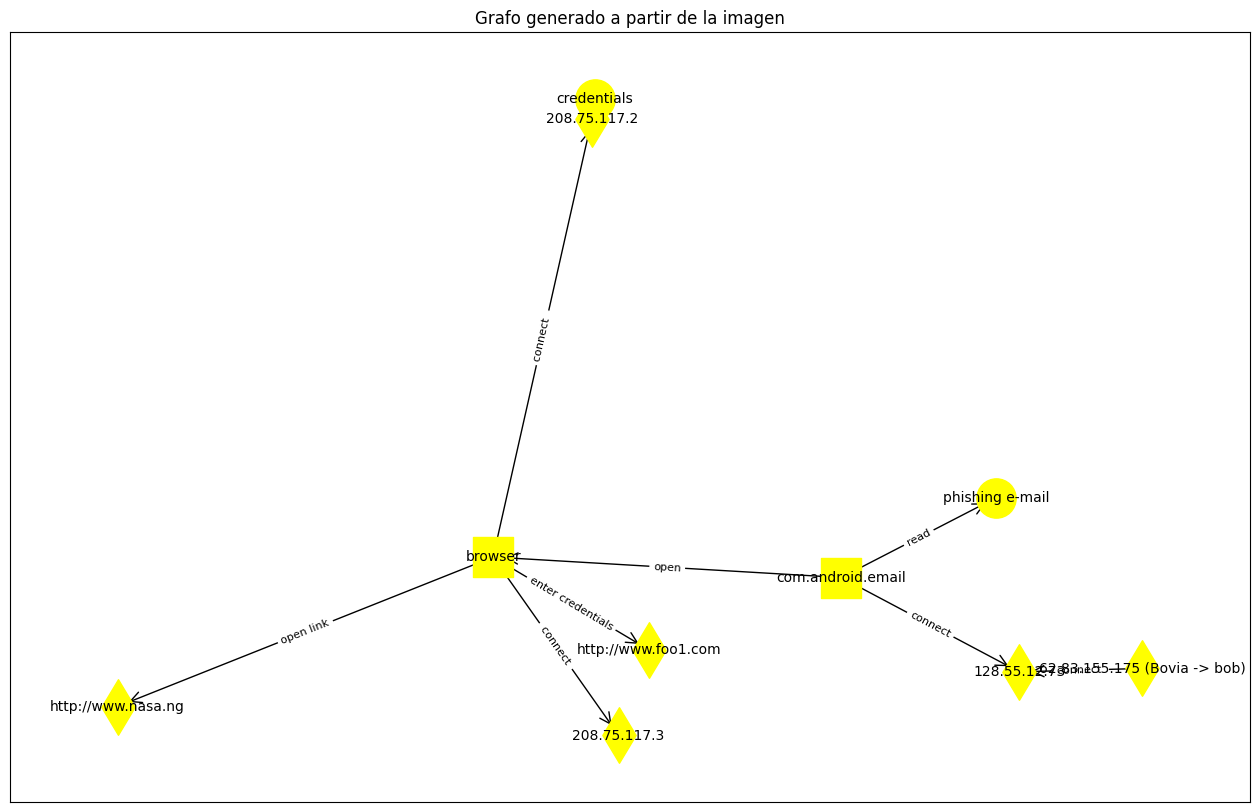

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear el grafo dirigido
G = nx.DiGraph()

# Definir los nodos con sus formas correspondientes
nodes_with_shapes = {
    "http://www.foo1.com": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "http://www.nasa.ng": {"shape": "diamond", "attackrelevant": "A", "type": "connection"},
    "credentials": {"shape": "ellipse", "attackrelevant": "A"},
    "208.75.117.2": {"shape": "diamond", "attackrelevant": "A"},
    "208.75.117.3": {"shape": "diamond", "attackrelevant": "A"},
    "browser": {"shape": "rectangle", "attackrelevant": "A"},
    "62.83.155.175 (Bovia -> bob)": {"shape": "diamond", "attackrelevant": "A"},
    "128.55.12.73": {"shape": "diamond", "attackrelevant": "A"},
    "phishing e-mail": {"shape": "ellipse", "attackrelevant": "A"},
    "com.android.email": {"shape": "rectangle", "attackrelevant": "A"},
}

# Añadir los nodos al grafo con el atributo "shape"
for node, dicti in nodes_with_shapes.items():
    G.add_node(node, shape=dicti["shape"], attackrelevant=dicti["attackrelevant"])

# Definir las aristas basadas en las relaciones observadas en el grafo
edges = [
    ("com.android.email", "128.55.12.73", {"label": "connect"}),
    ("com.android.email", "phishing e-mail", {"label": "read"}),
    ("com.android.email", "browser", {"label": "open"}),
    ("62.83.155.175 (Bovia -> bob)", "128.55.12.73", {"label": "connect "}),
    ("browser", "208.75.117.2", {"label": "connect "}),
    ("browser", "208.75.117.3", {"label": "connect "}),
    ("208.75.117.2", "credentials", {"label": "exfil"}),
    ("browser", "http://www.foo1.com", {"label": "enter credentials"}),
    ("browser", "http://www.nasa.ng",  {"label": "open link"}),
]

# Añadir las aristas al grafo con etiquetas
G.add_edges_from(edges)


# Exportar el grafo a formato GEXF
output_path = "./grafo2_E3.gexf"

nx.write_gexf(G, output_path)

# Dibujar el grafo
pos = nx.forceatlas2_layout(G)  # Ajustar distribución del layout
plt.figure(figsize=(16, 10))

# Dibujar nodos según su forma
shapes = set(nx.get_node_attributes(G, 'shape').values())
for shape in shapes:
    node_list = [node for node in G.nodes if G.nodes[node]['shape'] == shape]
    nx.draw_networkx_nodes(G, pos, nodelist=node_list, node_shape="open" if shape == "ellipse" else ("send" if shape == "rectangle" else "d"), node_color="yellow", node_size=800)

# Dibujar aristas y etiquetas de nodos
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10)

# Dibujar etiquetas de aristas
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Grafo generado a partir de la imagen")
plt.show()


# DARPA E5

## Figure 5: ClearScope AppStarter APK Micro APT

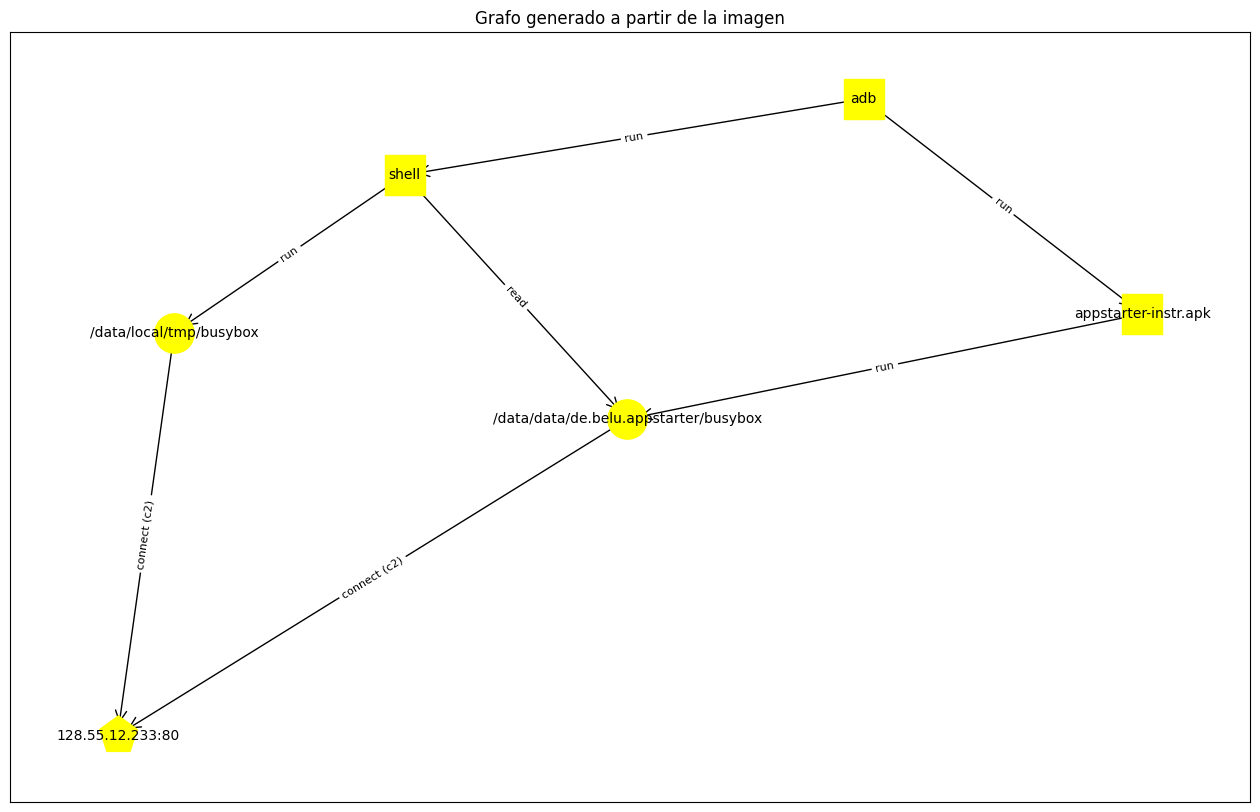

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear el grafo dirigido
G = nx.DiGraph()

# Definir los nodos con sus formas correspondientes
nodes_with_shapes = {
    "128.55.12.233:80": {"shape": "diamond", "attackrelevant": "A"},
    "/data/local/tmp/busybox": {"shape": "ellipse", "attackrelevant": "A"},
    "/data/data/de.belu.appstarter/busybox": {"shape": "ellipse", "attackrelevant": "A"},
    "shell": {"shape": "rectangle", "attackrelevant": "A"},
    "appstarter-instr.apk": {"shape": "rectangle", "attackrelevant": "A"},
    "adb": {"shape": "rectangle", "attackrelevant": "A"},
}

# Añadir los nodos al grafo con el atributo "shape"
for node, dicti in nodes_with_shapes.items():
    G.add_node(node, shape=dicti["shape"], attackrelevant=dicti["attackrelevant"])

# Definir las aristas basadas en las relaciones observadas en el grafo
edges = [
    ("adb", "shell", {"label": "run"}),
    ("adb", "appstarter-instr.apk", {"label": "install"}),
    ("adb", "appstarter-instr.apk", {"label": "run"}),
    ("appstarter-instr.apk", "/data/data/de.belu.appstarter/busybox", {"label": "write"}),
    ("appstarter-instr.apk", "/data/data/de.belu.appstarter/busybox", {"label": "run"}),
    ("shell", "/data/data/de.belu.appstarter/busybox", {"label": "read"}),
    ("shell", "/data/local/tmp/busybox", {"label": "write"}),
    ("shell", "/data/local/tmp/busybox", {"label": "run"}),
    ("/data/local/tmp/busybox", "128.55.12.233:80", {"label": "connect (c2)"}),
    ("/data/data/de.belu.appstarter/busybox", "128.55.12.233:80", {"label": "connect (c2)"}),
]

# Añadir las aristas al grafo con etiquetas
G.add_edges_from(edges)

# Exportar el grafo a formato GEXF
output_path = "./grafo1_E5.gexf"

nx.write_gexf(G, output_path)
# Dibujar el grafo
pos = nx.spring_layout(G, k=0.5)  # Ajustar distribución del layout
plt.figure(figsize=(16, 10))

# Dibujar nodos según su forma
shapes = set(nx.get_node_attributes(G, 'shape').values())
for shape in shapes:
    node_list = [node for node in G.nodes if G.nodes[node]['shape'] == shape]
    nx.draw_networkx_nodes(G, pos, nodelist=node_list, node_shape="open" if shape == "ellipse" else ("send" if shape == "rectangle" else "p"), node_color="yellow" if shape != "pentagon" else "cyan", node_size=800)

# Dibujar aristas y etiquetas de nodos
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10)

# Dibujar etiquetas de aristas
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Grafo generado a partir de la imagen")
plt.show()


## Figure 7: FiveDirections 1 Drakon APT Verifier

Tried multiple times to exploit the browser and use BITS to download and run the verifier executable.
This was done by browsing to http://215.237.119.171/config.html. At this point, Firefox should have
connected out to 68.149.51.179 to download and execute dbgstat.dll and tester.exe. We think the files
were downloaded but not executed, although we could find no instance of the files on disk where we
would expect them. Instead, we scp’ed the files to the target and ran them using an Administrator
command prompt. Tester.exe (verifier) opened dbgstat.dll (drakon.dll) and registered it as a verifier DLL
for Firefox in the Windows registry. The result is that every time a new Firefox process is started,
drakon.dll is injected into it automatically and executed. We configured the OC2 to automatically run the
same script each time a new connection was received, including hostname, whoami, and ps. We left the
drakon.dll verifier enabled throughout the remaining engagement, resulting in 126 drakon instances and
C2 connections.
The OC2 command script stopped working 100% after connection W10, working partially for some
connections and not at all for others. Not sure exactly what happened but it’s possible the browser had
slowed down to the point where drakon was unable to run any commands before benign activity closed
the browser. There were noticeable performance issues with Firefox on FiveDirections during this test,
and the benign activity would not have taken this into account.

The TA1 Five Directions attack consisted of the host browsing to the malicious website
http://215.237.119.171/config.html where a malicious dll named dbgstat.dll is downloaded. The delivery
method of the attack is the Application Verifier which is used to inject the Drakon APT into the Firefox
process. This attack utilizes the debugging capability built into Windows used to allow developers to
debug memory allocations and runtime resouces. Once the APT DLL has been loaded into Firefox, it
connects back to C2. This remains persistent and a connection to C2 is established each time Firefox is
launched.
In this attack the user relaunches Firefox four times and at callback gethostname, getusername, and
getprocesslist calls are made from the C2.

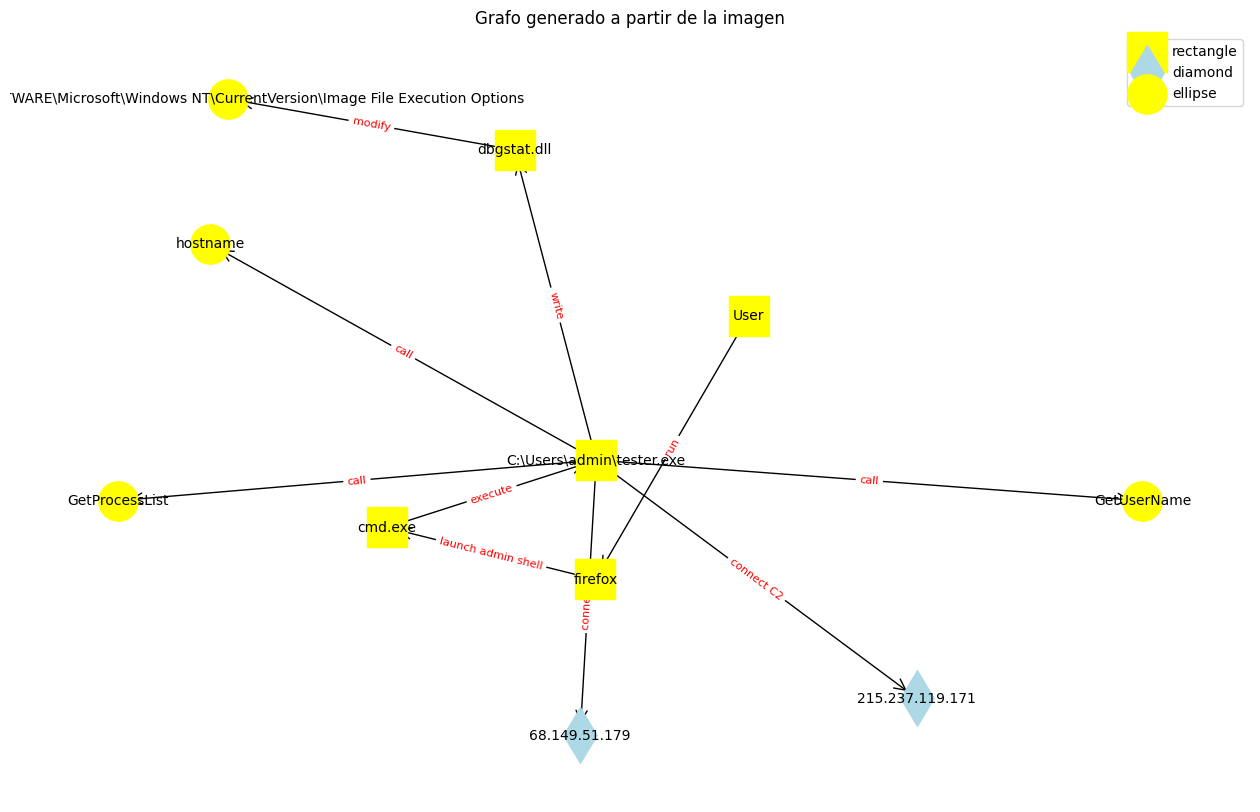

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear el grafo dirigido
G = nx.DiGraph()

# Definir los nodos con sus atributos (cada uno tiene un diccionario con la clave "shape")
nodes_with_shapes = {
    "User": {"shape": "rectangle", "attackrelevant": "A"},   # actor (usuario)
    "firefox": {"shape": "rectangle", "attackrelevant": "A"},   # proceso
    "cmd.exe": {"shape": "rectangle", "attackrelevant": "A"},   # proceso (shell con privilegios)
    "C:\\Users\\admin\\tester.exe": {"shape": "rectangle", "attackrelevant": "A"},  # proceso sospechoso
    "dbgstat.dll": {"shape": "rectangle", "attackrelevant": "A"},   # archivo DLL
    "HKLM\\SOFTWARE\\Microsoft\\Windows NT\\CurrentVersion\\Image File Execution Options": {"shape": "ellipse", "attackrelevant": "A"},  # clave de registro
    "GetUserName": {"shape": "ellipse", "attackrelevant": "A"},   # función del sistema
    "GetProcessList": {"shape": "ellipse", "attackrelevant": "A"},   # función del sistema
    "hostname": {"shape": "ellipse", "attackrelevant": "A"},   # función del sistema
    "68.149.51.179": {"shape": "diamond", "attackrelevant": "A"},  # dirección IP (nodo de red)
    "215.237.119.171": {"shape": "diamond", "attackrelevant": "A"}  # dirección IP (nodo de red)
}

# Agregar cada nodo al grafo con su atributo "shape"
for node, dicti in nodes_with_shapes.items():
    G.add_node(node, shape=dicti["shape"], attackrelevant=dicti["attackrelevant"])

# Definir las aristas (relaciones) con etiquetas descriptivas
edges = [
    ("User", "firefox", {"label": "run"}),
    ("User", "firefox", {"label": "run"}),
    ("User", "firefox", {"label": "run"}),
    ("firefox", "cmd.exe", {"label": "launch admin shell"}),
    ("cmd.exe", "C:\\Users\\admin\\tester.exe", {"label": "execute"}),
    ("C:\\Users\\admin\\tester.exe", "dbgstat.dll", {"label": "write"}),
    ("dbgstat.dll", "HKLM\\SOFTWARE\\Microsoft\\Windows NT\\CurrentVersion\\Image File Execution Options", {"label": "modify"}),
    ("C:\\Users\\admin\\tester.exe", "68.149.51.179", {"label": "connect C2"}),
    ("C:\\Users\\admin\\tester.exe", "215.237.119.171", {"label": "connect C2"}),
    ("C:\\Users\\admin\\tester.exe", "GetUserName", {"label": "call"}),
    ("C:\\Users\\admin\\tester.exe", "GetProcessList", {"label": "call"}),
    ("C:\\Users\\admin\\tester.exe", "hostname", {"label": "call"})
]

# Agregar las aristas al grafo
G.add_edges_from(edges)

# Exportar el grafo a formato GEXF
output_path = "./grafo2_E5.gexf"

nx.write_gexf(G, output_path)
# Dibujar el grafo
pos = nx.spring_layout(G, k=0.8, seed=42)  # Usamos un layout de resorte para distribuir los nodos

plt.figure(figsize=(16, 10))

# Dibujar nodos agrupados según su "shape"
# Se asignan distintas formas de dibujo según el valor del atributo:
#  - "ellipse": 'o'
#  - "rectangle": 's'
#  - "diamond": 'd'
shape_mapping = {
    "ellipse": "open",
    "rectangle": "send",
    "diamond": "d"
}

# Se extraen los diferentes tipos de forma
shapes = set(attr["shape"] for attr in nodes_with_shapes.values())

for shape in shapes:
    # Lista de nodos que tienen la forma actual
    nodelist = [node for node in G.nodes() if G.nodes[node]["shape"] == shape]
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodelist,
        node_shape=shape_mapping.get(shape, "open"),
        node_color="yellow" if shape != "diamond" else "lightblue",
        node_size=800,
        label=shape
    )

# Dibujar aristas y sus etiquetas
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10)

# Etiquetas para las aristas
edge_labels = {(u, v): data["label"] for u, v, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red", font_size=8)

plt.title("Grafo generado a partir de la imagen")
plt.axis("off")
plt.legend(scatterpoints=1)
plt.show()


# GRAFO KAIROS

In [3]:

# Crear un grafo dirigido
G = nx.DiGraph()

# A = Attack related
# B = Benign
# Definición de nodos con forma como atributo (extraído visualmente del grafo)
nodes = {
    "Firefox": {"shape": "rectangle", "attackrelevant" : 'A'},
    "104.228.117.212": {"shape": "diamond", "attackrelevant" : 'A'},
    "141.43.176.203": {"shape": "diamond", "attackrelevant" : 'A'},
    "home/admin/profile": {"shape": "ellipse", "attackrelevant" : 'A'},
    "home/admin/clean": {"shape": "ellipse", "attackrelevant" : 'A'},
    "profile": {"shape": "ellipse", "attackrelevant" : 'A'},
    "clean": {"shape": "ellipse", "attackrelevant" : 'A'},
    "146.153.68.151": {"shape": "diamond", "attackrelevant" : 'A'},
    "/bin/dash": {"shape": "ellipse", "attackrelevant" : 'B'},
    "/etc/passwd": {"shape": "ellipse", "attackrelevant" : 'A'},
    "gtcache": {"shape": "rectangle", "attackrelevant" : 'A'},
    "/dev/glx_alsa_675": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/tmp/memtrace.so": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/var/log/xdev": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/var/log/wdev": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/var/log/mail": {"shape": "ellipse", "attackrelevant" : 'A'},
    "161.116.88.72": {"shape": "diamond", "attackrelevant" : 'A'},
    "149.52.198.23": {"shape": "diamond", "attackrelevant" : 'A'},
    "mail": {"shape": "rectangle", "attackrelevant" : 'A'},
    "group": {"shape": "ellipse", "attackrelevant" : 'B'},
    "/proc/*": {"shape": "ellipse", "attackrelevant" : 'B'},
    "127.0.0.1": {"shape": "diamond", "attackrelevant" : 'B'},
    "fluxbox": {"shape": "ellipse", "attackrelevant" : 'B'},
    "crashreporter": {"shape": "ellipse", "attackrelevant" : 'A'},
    "profile2": {"shape": "ellipse", "attackrelevant" : 'A'}
}

# Añadir nodos al grafo con la forma como atributo
for node, dicti in nodes.items():
    G.add_node(node, shape=dicti["shape"], attackrelevant=dicti["attackrelevant"])

# Definición de las aristas (extraído visualmente del grafo)
edges = [
    ("Firefox", "104.228.117.212", {"action": "send"}),
    ("104.228.117.212", "Firefox", {"action": "receive"}),
    ("Firefox", "141.43.176.203", {"action": "send"}),
    ("141.43.176.203", "Firefox", {"action": "receive"}),

    ("Firefox", "clean", {"action": "create"}),

    ("Firefox", "home/admin/profile", {"action": "write"}),
    ("Firefox", "home/admin/clean", {"action": "write"}),
    ("Firefox", "146.153.68.151", {"action": "send"}),
    ("146.153.68.151", "Firefox", {"action": "receive"}),
    ("Firefox", "/dev/glx_alsa_675", {"action": "open"}),
    ("crashreporter", "/dev/glx_alsa_675", {"action": "write"}),
    ("fluxbox", "/dev/glx_alsa_675", {"action": "write"}),
    ("gtcache", "/dev/glx_alsa_675", {"action": "open"}),

    ("profile", "home/admin/profile", {"action": "execute"}),
    ("profile", "profile", {"action": "create"}),
    ("clean", "home/admin/clean", {"action": "execute"}),
    ("clean", "clean", {"action": "create"}),
    ("/bin/dash", "146.153.68.151", {"action": "send"}),
    ("146.153.68.151", "/bin/dash", {"action": "receive"}),
    ("146.153.68.151", "gtcache", {"action": "receive"}),
    ("gtcache", "146.153.68.151", {"action": "send"}),
    ("/proc/*", "gtcache", {"action": "read"}),
    ("gtcache", "/proc/*", {"action": "open"}),
    ("gtcache", "127.0.0.1", {"action": "send"}),
    
    ("profile", "161.116.88.72", {"action": "send"}),
    ("161.116.88.72", "profile", {"action": "receive"}),
    ("clean", "161.116.88.72", {"action": "send"}),
    ("161.116.88.72", "clean", {"action": "receive"}),
    ("/etc/passwd", "clean", {"action": "read"}),
    ("/etc/passwd", "gtcache", {"action": "read"}),
    ("group", "gtcache", {"action": "read"}),
    ("gtcache", "/tmp/memtrace.so", {"action": "write"}),

    ("profile", "/var/log/mail", {"action": "write"}),
    ("mail", "/var/log/mail", {"action": "execute"}),
    ("gtcache", "/var/log/xdev", {"action": "open"}),
    ("gtcache", "/var/log/wdev", {"action": "open"}),
    ("149.52.198.23", "mail", {"action": "receive"}),
    ("mail", "149.52.198.23", {"action": "send"}),

    ("profile", "profile2", {"action": "create"}),
    ("profile2", "/var/log/xdev", {"action": "write"}),
    ("profile2", "/var/log/wdev", {"action": "write"}),
]

# Añadir aristas al grafo
G.add_edges_from(edges)

# Exportar el grafo a formato GEXF
output_path = "./graphs/grafo_kairos.gexf"

nx.write_gexf(G, output_path)
#pos = nx.forceatlas2_layout(G)
#nx.draw(G, pos=pos, with_labels = True)

In [6]:

# Crear un grafo dirigido
G = nx.DiGraph()

# A = Attack related
# B = Benign
# Definición de nodos con forma como atributo (extraído visualmente del grafo)
nodes = {
    "Firefox": {"shape": "rectangle", "attackrelevant" : 'A'},
    "home/admin/profile": {"shape": "ellipse", "attackrelevant" : 'A'},
    "home/admin/clean": {"shape": "ellipse", "attackrelevant" : 'A'},
    "profile": {"shape": "ellipse", "attackrelevant" : 'A'},
    "clean": {"shape": "ellipse", "attackrelevant" : 'A'},
    "146.153.68.151": {"shape": "diamond", "attackrelevant" : 'A'},
    "/bin/dash": {"shape": "ellipse", "attackrelevant" : 'B'},
    "/etc/passwd": {"shape": "ellipse", "attackrelevant" : 'A'},
    "gtcache": {"shape": "rectangle", "attackrelevant" : 'A'},
    "/dev/glx_alsa_675": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/tmp/memtrace.so": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/var/log/xdev": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/var/log/wdev": {"shape": "ellipse", "attackrelevant" : 'A'},
    "/var/log/mail": {"shape": "ellipse", "attackrelevant" : 'A'},
    "161.116.88.72": {"shape": "diamond", "attackrelevant" : 'A'},
    "149.52.198.23": {"shape": "diamond", "attackrelevant" : 'A'},
    "mail": {"shape": "rectangle", "attackrelevant" : 'A'},
    "/proc/*": {"shape": "ellipse", "attackrelevant" : 'B'},
    "127.0.0.1": {"shape": "diamond", "attackrelevant" : 'B'},
    "profile2": {"shape": "ellipse", "attackrelevant" : 'A'},
    "104.228.117.212": {"shape": "diamond", "attackrelevant" : 'A'},
    "141.43.176.203": {"shape": "diamond", "attackrelevant" : 'A'}
}

# Añadir nodos al grafo con la forma como atributo
for node, dicti in nodes.items():
    G.add_node(node, shape=dicti["shape"], attackrelevant=dicti["attackrelevant"])

# Definición de las aristas (extraído visualmente del grafo)
edges = [
    ("Firefox", "104.228.117.212", {"action": "send"}),
    ("Firefox", "141.43.176.203", {"action": "send"}),

    ("Firefox", "clean", {"action": "create"}),

    ("Firefox", "home/admin/profile", {"action": "write"}),
    ("Firefox", "home/admin/clean", {"action": "write"}),
    ("Firefox", "146.153.68.151", {"action": "send"}),
    ("Firefox", "/dev/glx_alsa_675", {"action": "open"}),
    ("gtcache", "/dev/glx_alsa_675", {"action": "open"}),

    ("profile", "home/admin/profile", {"action": "execute"}),
    ("profile", "profile", {"action": "create"}),
    ("clean", "home/admin/clean", {"action": "execute"}),
    ("clean", "clean", {"action": "create"}),
    ("146.153.68.151", "/bin/dash", {"action": "receive"}),
    ("gtcache", "146.153.68.151", {"action": "send"}),
    ("gtcache", "/proc/*", {"action": "open"}),
    ("gtcache", "127.0.0.1", {"action": "send"}),
    
    ("profile", "161.116.88.72", {"action": "send"}),
    ("161.116.88.72", "profile", {"action": "receive"}),
    ("clean", "161.116.88.72", {"action": "send"}),
    ("161.116.88.72", "clean", {"action": "receive"}),
    ("/etc/passwd", "clean", {"action": "read"}),
    ("/etc/passwd", "gtcache", {"action": "read"}),
    ("gtcache", "/tmp/memtrace.so", {"action": "write"}),

    ("profile", "/var/log/mail", {"action": "write"}),
    ("mail", "/var/log/mail", {"action": "execute"}),
    ("gtcache", "/var/log/xdev", {"action": "open"}),
    ("gtcache", "/var/log/wdev", {"action": "open"}),
    ("mail", "149.52.198.23", {"action": "send"}),

    ("profile", "profile2", {"action": "create"}),
    ("profile2", "/var/log/xdev", {"action": "write"}),
    ("profile2", "/var/log/wdev", {"action": "write"}),
]

# Añadir aristas al grafo
G.add_edges_from(edges)

# Exportar el grafo a formato GEXF
output_path = "./graphs/grafo_kairos.gexf"

nx.write_gexf(G, output_path)
#pos = nx.forceatlas2_layout(G)
#nx.draw(G, pos=pos, with_labels = True)

# Graph MORSE

# Graph MEMOR*

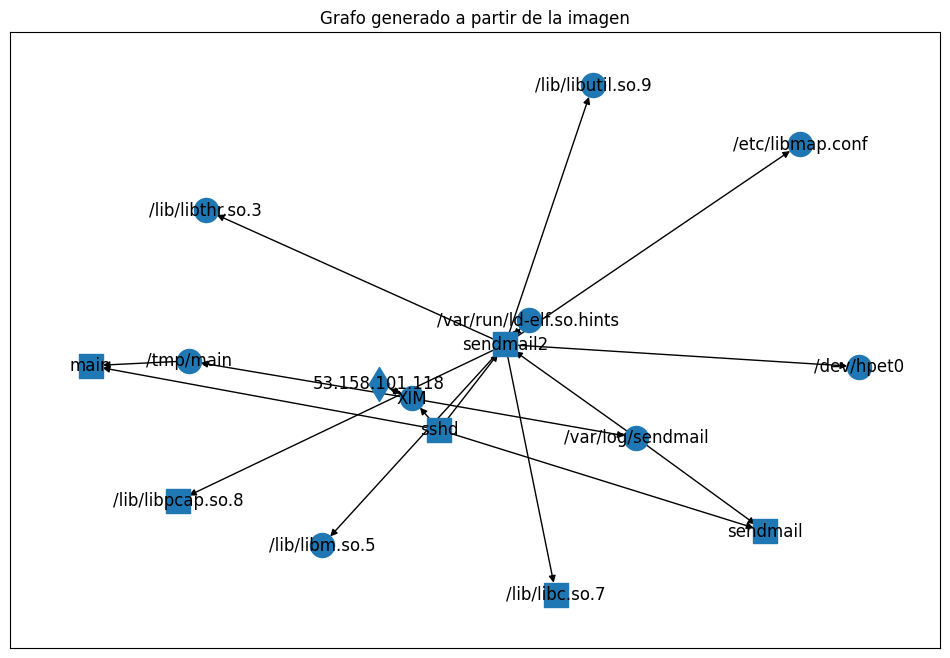

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear el grafo dirigido
G = nx.DiGraph()

# Definir los nodos con su forma asociada
nodes_with_shapes = {
    "53.158.101.118": {"shape": "diamond", "attackrelevant": "A"},
    "XIM": {"shape": "ellipse", "attackrelevant": "A"},
    "/tmp/main": {"shape": "ellipse", "attackrelevant": "A"},
    "sendmail": {"shape": "rectangle", "attackrelevant": "A"},
    "sendmail2": {"shape": "rectangle", "attackrelevant": "A"},
    "sshd": {"shape": "rectangle", "attackrelevant": "A"},
    "main": {"shape": "rectangle", "attackrelevant": "A"},
    "/var/log/sendmail": {"shape": "ellipse", "attackrelevant": "A"},
    "/etc/libmap.conf": {"shape": "ellipse", "attackrelevant": "B"},
    "/var/run/ld-elf.so.hints": {"shape": "ellipse", "attackrelevant": "B"},
    "/lib/libthr.so.3": {"shape": "ellipse", "attackrelevant": "B"},
    "/lib/libm.so.5": {"shape": "ellipse", "attackrelevant": "B"},
    "/lib/libutil.so.9": {"shape": "ellipse", "attackrelevant": "B"},
    "/dev/hpet0": {"shape": "ellipse", "attackrelevant": "B"},
    "/lib/libc.so.7": {"shape": "rectangle", "attackrelevant": "B"},
    "/lib/libpcap.so.8": {"shape": "rectangle", "attackrelevant": "B"}
}

# Añadir los nodos al grafo con el atributo "shape"
for node, dicti in nodes_with_shapes.items():
    G.add_node(node, shape=dicti["shape"], attackrelevant=dicti["attackrelevant"])

# Definir las aristas basadas en las relaciones observadas en el grafo
edges = [
    ("53.158.101.118", "XIM"),
    ("XIM", "53.158.101.118"),
    ("XIM", "/tmp/main"),
    ("/tmp/main", "main"),
    ("sshd", "sendmail"),
    ("sshd", "sendmail2"),
    ("sshd", "main"),
    ("sshd", "XIM"),
    ("XIM", "/var/log/sendmail"),
    ("/var/log/sendmail", "sendmail"),
    ("/var/log/sendmail", "sendmail2"),
    ("sendmail2", "/etc/libmap.conf"),
    ("sendmail2", "/var/run/ld-elf.so.hints"),
    ("/var/run/ld-elf.so.hints", "sendmail2"),
    ("sendmail2", "/lib/libthr.so.3"),
    ("sendmail2", "/lib/libm.so.5"),
    ("sendmail2", "/lib/libutil.so.9"),
    ("sendmail2", "/dev/hpet0"),
    ("sendmail2", "/lib/libc.so.7"),
    ("sendmail2", "/lib/libpcap.so.8")
]

# Añadir las aristas al grafo
G.add_edges_from(edges)

# Exportar el grafo a formato GEXF
output_path = "./grafo_memor.gexf"

nx.write_gexf(G, output_path)
# Dibujar el grafo
pos = nx.spring_layout(G)  # Layout para distribuir los nodos
shapes = set(nx.get_node_attributes(G, 'shape').values())

plt.figure(figsize=(12, 8))
for shape in shapes:
    node_list = [node for node in G.nodes if G.nodes[node]['shape'] == shape]
    nx.draw_networkx_nodes(G, pos, nodelist=node_list, label=shape, node_shape="open" if shape == "ellipse" else ("send" if shape == "rectangle" else "d"))

nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)
plt.title("Grafo generado a partir de la imagen")
plt.show()


# Grafo Sometimes

Archivo GEXF guardado en: grafo_sometimes.gexf


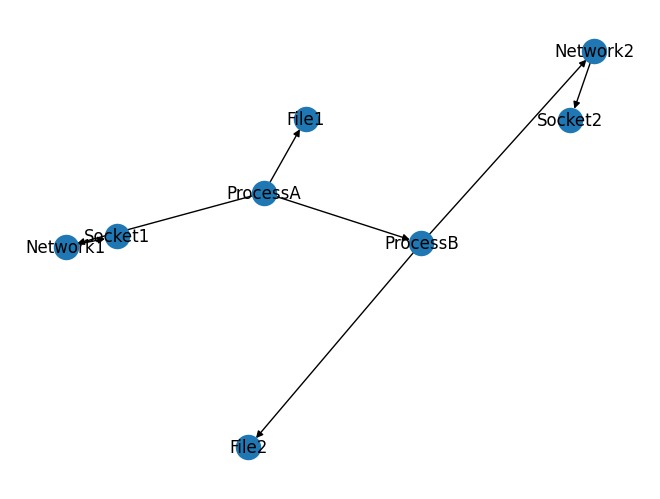

In [6]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# Definición de nodos con atributo ""shape""
nodes = {
    "ProcessA": "rectangle",  # Proceso representado como rectángulo
    "ProcessB": "rectangle",
    "File1": {"shape": "ellipse", "attackrelevant" : 'A'},       # Archivo representado como elipse
    "File2": {"shape": "ellipse", "attackrelevant" : 'A'},
    "Network1": "diamond",    # Red representada como rombo
    "Network2": "diamond",
    "Socket1": {"shape": "ellipse", "attackrelevant" : 'A'},
    "Socket2": {"shape": "ellipse", "attackrelevant" : 'A'},
}

# Añadir nodos al grafo con el atributo '"shape"'
for node, "shape" in nodes.items():
    G.add_node(node, "shape"="shape")

# Definición de las aristas con el tipo de conexión
edges = [
    ("ProcessA", "ProcessB", {"attackrelevant": "Clone"}),
    ("ProcessA", "File1", {"attackrelevant": "Read"}),
    ("ProcessA", "Network1", {"attackrelevant": "Connect"}),
    ("ProcessB", "File2", {"attackrelevant": "Write"}),
    ("ProcessB", "Network2", {"attackrelevant": "Send"}),
    ("Network1", "Socket1", {"attackrelevant": "Recv"}),
    ("Network2", "Socket2", {"attackrelevant": "Recv"}),
]

# Añadir aristas al grafo
G.add_edges_from(edges)

# Exportar el grafo a un archivo GEXF
output_path = "grafo_sometimes.gexf"
nx.write_gexf(G, output_path)

print(f"Archivo GEXF guardado en: {output_path}")

pos = nx.forceatlas2_layout(G)
nx.draw(G, pos=pos, with_labels = True)


# Graph MEMOR (bis)*

# Grafo FLASH

# Grafos NODLINK